## Лавренов Константин ЭФБО-02-24

###  1.1

In [6]:
!pip install sympy

mambajs 0.21.4

Process pip requirements ...

Requirement sympy already satisfied.


In [7]:
import numpy as np
import scipy.linalg as la
from sympy import *
init_printing()

In [8]:
A=np.array([[1,5,-2,0],[-3,1,9,-5],[4,-8,-1,7]])
b=np.array([-7,9,0]).reshape(3,1)
A_b = np.hstack([A,b])
Matrix(A_b).rref()

⎛⎡1  0  0  8/7   -11/7⎤           ⎞
⎜⎢                    ⎥           ⎟
⎜⎢0  1  0  -2/7  -6/7 ⎥, (0, 1, 2)⎟
⎜⎢                    ⎥           ⎟
⎝⎣0  0  1  -1/7   4/7 ⎦           ⎠

### 1.2

In [16]:
A=np.array([[5,-1,5,9,-2],[3,0,6,9,-1],[2,0,4,6,-1]])
b=np.array([-3,4,0]).reshape(3,1)
A_b = Matrix(np.hstack([A,b]))
rref, piv = A_b.rref()
print("a) rref(A|b):")
display(rref)

x1, x2, x3, x4, x5 = symbols('x1 x2 x3 x4 x5')
vars = [x1, x2, x3, x4, x5]
sol = linsolve(A_b, vars)
print("б)")
display(sol)

a) rref(A|b):


⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

б)


### 1.3

In [22]:
x, y, z, u = symbols('x y z u')

M = Matrix([
    [97, 90, 48, 47 - 32*x],
    [84, 91, 54, 40 - 35*x],
    [18, 21, 13, 37 - 17*x]
])

sol = solve_linear_system(M, y, z, u)
a = sol[y].coeff(x, 0)
b = sol[y].coeff(x, 1)

print(f"a = {a}")
print(f"b = {b}")

M1 = Matrix([
    [97, 90, 48],
    [84, 91, 54],
    [18, 21, 13]
])
det_M = M1.det()
print(f"Определитель: = {det_M}")

a = 14027
b = -4262
Определитель: = 1


Так как определитель матрицы коэффициентов равен 1 != 0, => по теореме Крамера система имеет единственное решение, поэтому y можно представить как функцию от x вида y = ax + b

### 1.4

In [23]:
A = Matrix([
    [3, 0, 2],
    [0, 1, 3],
    [2, 2, 0],
    [0, 1, 0]
])

B = Matrix([
    [1, 2, -1, 2],
    [-2, 1, 1, 2],
    [2, 1, 1, 2]
])

C = Matrix([
    [0, -4, 6, 1],
    [2, 2, -5, -2],
    [2, -2, 6, 4],
    [1, 3, 0, 1]
])

Result = A * B + C
display(Result)

⎡7   4  5   11⎤
⎢             ⎥
⎢6   6  -1  6 ⎥
⎢             ⎥
⎢0   4  6   12⎥
⎢             ⎥
⎣-1  4  1   3 ⎦

### 1.5

In [25]:
n = Symbol('n')

for dim in range(1, 5):
    A1 = Matrix(dim, dim, lambda i, j: min(i+1, j+1))
    A2 = Matrix(dim, dim, lambda i, j: max(i+1, j+1))
    A3 = Matrix(dim, dim, lambda i, j: abs(i - j))
    print(f"n = {dim}; a) {A1.det()};  б) {A2.det()}; в) {A3.det()}")

n = 1; a) 1;  б) 1; в) 0
n = 2; a) 1;  б) -2; в) -1
n = 3; a) 1;  б) 3; в) 4
n = 4; a) 1;  б) -4; в) -12


### 1.7

In [30]:
n = 80000
a11 = 0.99
ann = 1.01
a12 = 0.57
a21 = 0.03

d = np.linspace(a11, ann, n)

a22 = d[1]
det_A = (a11 * a22 - a12 * a21) * np.prod(d[2:])
log_det = np.log(a11 * a22 - a12 * a21) + np.sum(np.log(d[2:]))
det_val = np.exp(log_det)

det_2x2 = a11 * a22 - a12 * a21
inv_a11 = a22 / det_2x2
inv_a22 = a11 / det_2x2
tr_inv = inv_a11 + inv_a22 + np.sum(1.0 / d[2:])

print(f"1) {det_val:.3f}")
print(f"2) {tr_inv:.3f}")

1) 0.259
2) 80002.703


### 1.8

In [32]:
n = 43000
d = np.geomspace(1.0, 1.07, n)
r1 = np.linspace(d[0], 1.10, n)

min_elem = np.min([-r1[j] / (d[0] * d[j]) for j in range(1, n)])
sum_B = np.sum(1.0 / d) + np.sum([-r1[j] / (d[0] * d[j]) for j in range(1, n)])

print(f"1) {min_elem:.3f}")
print(f"2) {sum_B:.1f}")

1) -1.028
2) -2054.4


### 1.9

In [33]:
gamma = 0.057
A = np.array([[7*gamma, 14*gamma], [9*gamma, 1*gamma]])
I = np.eye(2)

S_4_70 = sum(np.linalg.matrix_power(A, i) for i in range(4, 71))
ans1 = np.max(S_4_70)

B_4 = np.linalg.inv(I - A) @ np.linalg.matrix_power(A, 4)
ans2 = np.max(B_4)

k = 1
while True:
    S_limit = np.linalg.inv(I - A) @ np.linalg.matrix_power(A, k)
    if np.max(S_limit) < 0.0002:
        break
    k += 1

print(f"1) {ans1:.6f}")
print(f"2) {ans2:.6f}")
print(f"3) {k}")

1) 3.609679
2) 3.611175
3) 89


### 1.10

In [34]:
x = Symbol('x')
M = Matrix([
    [7, 5, 5, x],
    [2, 2, 6, 9],
    [3, x, 8, 0],
    [3, 1, 1, 0]
])

det_M = M.det().expand()
poly_M = Poly(det_M, x)

a = poly_M.coeff_monomial(x**2)
b = poly_M.coeff_monomial(x**1)
c = poly_M.coeff_monomial(x**0)

print(f"Многочлен: {det_M}")
print(f"1) a = {a}")
print(f"2) c = {c}")

Многочлен: 16*x**2 - 116*x + 576
1) a = 16
2) c = 576


### 1.11

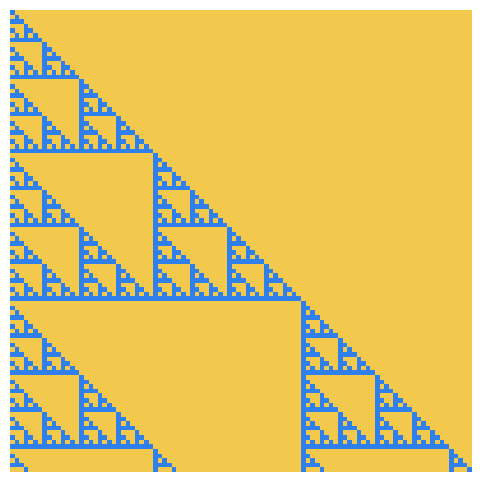

In [35]:
import matplotlib.pyplot as plt
from scipy.special import comb

n = 100
M = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1):
        M[i, j] = comb(i + 1, j + 1, exact=True) % 2

cmap = plt.cm.colors.ListedColormap(['#F2C94C', '#2F80ED'])

plt.figure(figsize=(6, 6))
plt.imshow(M, cmap=cmap)
plt.axis('off')
plt.show()

### 1.12

а)


array([[1]])

array([[ 1,  1],
       [ 1, -1]])

array([[ 1,  1,  1,  1],
       [ 1, -1,  1, -1],
       [ 1,  1, -1, -1],
       [ 1, -1, -1,  1]])

б) H4 действительно равно H2 x H2: True
в) Проверка свойства H_8 * H_8^T == 8 * I_8: True


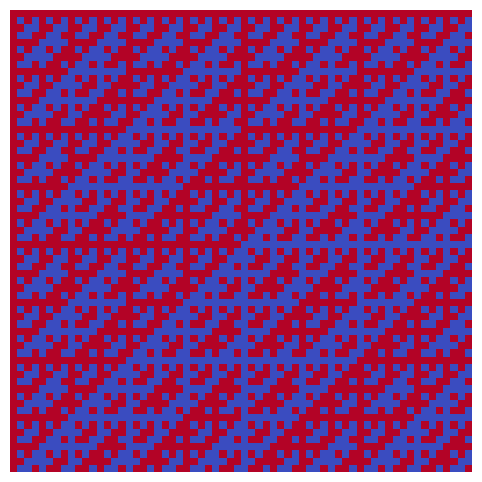

In [41]:
H1 = np.array([[1]])
H2 = np.array([[1, 1], [1, -1]])
H4 = np.kron(H2, H2)
H64 = H2
for _ in range(5):
    H64 = np.kron(H2, H64)

print("а)")
display(H1)
display(H2)
display(H4)

H4_manual = np.array([
    [1,  1,  1,  1],
    [1, -1,  1, -1],
    [1,  1, -1, -1],
    [1, -1, -1,  1]
])

is_equal = np.array_equal(H4, H4_manual)
print(f"б) H4 действительно равно H2 x H2: {is_equal}")

def get_hadamard(k):
    H = np.array([[1]])
    H2 = np.array([[1, 1], [1, -1]])
    for _ in range(k):
        H = np.kron(H2, H)
    return H

H8 = get_hadamard(3)
ortho_check = np.array_equal(H8 @ H8.T, 8 * np.eye(8))
print(f"в) Проверка свойства H_8 * H_8^T == 8 * I_8: {ortho_check}")

plt.figure(figsize=(6, 6))
plt.imshow(H64, cmap='mako_r' if 'mako_r' in plt.colormaps() else 'coolwarm')
plt.axis('off')
plt.show()

### 1.13

In [42]:
A = Matrix([
    [14, 10, 21],
    [12, 15, 26],
    [18, 11, 27]
])

eigenvals = A.eigenvects()

max_im = -1
target_eval = None
target_evec = None

for eval_val, mult, evecs in eigenvals:
    im_part = N(im(eval_val))
    if im_part > max_im:
        max_im = im_part
        target_eval = eval_val
        target_evec = evecs[0]

v = target_evec / target_evec[0]
U = v[1]

print(f"1) {N(im(target_eval)):.4f}")
print(f"2) {N(re(U)):.4f}")

1) 0.3448
2) 3.7478


### 1.14

In [71]:
A = Matrix([
    [-3,  7, -6, -1,  8, -3, -2],
    [ 1, -5,  8, -3, -5,  4, -5],
    [ 1,  3, -4,  6, -2,  0,  8],
    [-1, 11,-12,  9,  3, -3,  9],
    [-3, 11,-12,  5,  8, -4,  6],
    [-3,  2,  1, -4,  4,  1, -7],
    [ 1, -5,  6, -2, -4,  3, -2]
])

E = eye(7)
powers = [E]

for k in range(1, 8):
    powers.append(powers[-1] * A)

    B = Matrix.hstack(*[
        powers[i].reshape(49, 1)
        for i in range(k + 1)
    ])

    if B.rank() < k + 1:
        c = B.nullspace()[0]
        c = [simplify(ci / c[-1]) for ci in c]
        
        min_poly = factor(sum(c[i] * x**i for i in range(k + 1)))
        display(min_poly)
        break


### 1.15

In [52]:
A = Matrix([
    [17, -8, 4],
    [-8, 17, -4],
    [4, -4, 11]
])

P, D = A.diagonalize()

cols = [P.col(i) for i in range(P.cols)]

P_ortho = GramSchmidt(cols, orthonormal=True)

print("Матрица")
display(D)

print("Ортонормированный базис:")
for i, v in enumerate(P_ortho, 1):
    print(f"v_{i}:")
    display(v)

Матрица


⎡9  0  0 ⎤
⎢        ⎥
⎢0  9  0 ⎥
⎢        ⎥
⎣0  0  27⎦

Ортонормированный базис:
v_1:


⎡√2⎤
⎢──⎥
⎢2 ⎥
⎢  ⎥
⎢√2⎥
⎢──⎥
⎢2 ⎥
⎢  ⎥
⎣0 ⎦

v_2:


⎡-√2 ⎤
⎢────⎥
⎢ 6  ⎥
⎢    ⎥
⎢ √2 ⎥
⎢ ── ⎥
⎢ 6  ⎥
⎢    ⎥
⎢2⋅√2⎥
⎢────⎥
⎣ 3  ⎦

v_3:


⎡2/3 ⎤
⎢    ⎥
⎢-2/3⎥
⎢    ⎥
⎣1/3 ⎦

### 1.16

In [58]:
A = Matrix([
    [3, 4, 0, 0],
    [4, -3, 0, 0],
    [0, 0, 4, -2],
    [0, 0, -2, 1]
])

P, D = A.diagonalize()
display(D)

Канонический вид (диагональ):


⎡-5  0  0  0⎤
⎢           ⎥
⎢0   0  0  0⎥
⎢           ⎥
⎢0   0  5  0⎥
⎢           ⎥
⎣0   0  0  5⎦

### 1.17

In [59]:
A_a = Matrix([[5, 2], [2, 8]])
evals_a = A_a.eigenvals()
print(f"a) {evals_a}")

A_b = Matrix([[5, 6], [6, 0]])
evals_b = A_b.eigenvals()
print(f"б) {evals_b}")

a) {9: 1, 4: 1}
б) {9: 1, -4: 1}


In [ ]:
a) Эллипс, каноническое уравнение: x^2/4 + y^2/9 = 1
б) Гипербола, каноническое уравнение: x^2/4 - y^2/9 = 1 

### 1.18

In [66]:
lam = Symbol('lambda')
A = Matrix([
    [1, lam, 5],
    [lam, 4, 3],
    [5, 3, 1]
])

D1 = A[0:1, 0:1].det()
D2 = A[0:2, 0:2].det()
D3 = A.det()

print(f"D1 = {D1}")
print(f"D2 = {D2}")
print(f"D3 = {D3}")

print("Так как D1 > 0, находим пересечение неравенств D2 > 0 и D3 > 0:")

sol_D2 = solve_univariate_inequality(D2 > 0, lam, relational=False)
sol_D3 = solve_univariate_inequality(D3 > 0, lam, relational=False)

intersection = sol_D2.intersect(sol_D3)
print(intersection)

D1 = 1
D2 = 4 - lambda**2
D3 = -lambda**2 + 30*lambda - 105
Так как D1 > 0, находим пересечение неравенств D2 > 0 и D3 > 0:
EmptySet


### 1.19

In [62]:
lam = Symbol('lambda')
A = Matrix([
    [lam, 1, -1],
    [1, -2, 1],
    [-1, 1, -3]
])

D1 = A[0:1, 0:1].det()
D2 = A[0:2, 0:2].det()
D3 = A.det()

sol = solve([D1 < 0, D2 > 0, D3 < 0], lam)
print(sol)

(-oo < lambda) & (lambda < -3/5)


### 1.20

In [64]:
A1 = Matrix([
    [2, 4, -2],
    [4, 9, -5],
    [-2, -5, 3]
])

A2 = Matrix([
    [2, -2, -2],
    [-2, 3, 4],
    [-2, 4, 6]
])

sig1 = (sum(1 for e in A1.eigenvals() if e > 0), sum(1 for e in A1.eigenvals() if e < 0))
sig2 = (sum(1 for e in A2.eigenvals() if e > 0), sum(1 for e in A2.eigenvals() if e < 0))

print(f"Эквивалентны: {sig1 == sig2}")

Эквивалентны: True
